# EDA v2 — `papers_combined.parquet`, target = `triage_label` (binarized)

**Author:** SF · **Branch:** `SF-eda-firstrun` · **Scope:** read-only exploratory analysis,
no files written back to `data/`.

## What this notebook is

This is **v2** of the EDA pass on `data/processed/papers_combined.parquet` (2,873 papers
across 6 research questions — see `data/processed/README.md` for the full data card). It
supersedes `sf_eda_firstrun.ipynb`, which is kept in place as a historical record, not
deleted — this repo's convention for iterating on a decision trail is to add a next
version, not overwrite the one a decision was made from.

v1 was reviewed against this bootcamp's own EDA curriculum (`DS-EDA-Tutorial`,
`DS-featureeng`, `DS-hypothesis-testing`, plus the applied `DS-airpollutionproject`
capstone) as a critical-thinking exercise. That review found v1's execution disciplined —
hard-finding/judgement-call labelling, independent re-derivation instead of trusting
prior reports — but surfaced concrete gaps this version closes:

1. **Target framing, resolved, not hedged.** v1 presented a binary (`positive`/`negative`)
   and a full 3-class reading side by side rather than committing to one. **This has now
   been decided**: the target is binarized. `pass` is dropped from the modelling target —
   not because it's uninteresting, but because §2 below shows it's overwhelmingly a proxy
   for "no abstract to triage," not a relevance judgement. See §2.4 for the evidence and
   the decision statement.
2. **A real leakage bug fixed.** v1's baseline CV (§13) fit `StandardScaler` on the full
   feature matrix before splitting into folds — the scaler saw test-fold rows. Fixed here:
   scaling is fit on the training fold only, inside the CV loop, exactly the
   `DS-featureeng` "fit-on-train-only" discipline this repo already follows for cleaning.
3. **Descriptive claims that were asserted are now tested.** v1 called the citation-count/
   `positive`-vs-`negative` inversion "real signal, not noise" from a `.corr()`/mean-only
   read, with no formal test — consistent with how this bootcamp's own applied capstone
   project makes the same kind of claim, but not backed by the significance-testing
   machinery the curriculum teaches when it's actually invoked. §7.1 now runs a
   Mann-Whitney U test on that exact claim — and the result changes the finding (§7.1).
4. **Model-ranking confidence now checked, not eyeballed.** v1 flagged that
   `HistGradientBoostingClassifier`'s lead over `RandomForestClassifier` was smaller than
   one fold's own standard deviation, but still presented a "1st/2nd/3rd" ranking. §13 now
   runs the same paired fold-level significance test this repo already built for exactly
   this question (`notebooks/experiments/run_comparisons.ipynb` §4) instead of re-inventing
   one.
5. **Ranking-relevant metrics added.** The eventual use of any baseline here is ranking the
   478 never-reviewed papers for a human to screen — this repo already has
   `recall_at_Xpct`/`wss_at_95` as its standard citation-screening metrics
   (`scripts/embedding_utils.py`). §13 now reports them for the classifier
   candidates, not ROC-AUC alone.
6. **The held-out-use-case generalization gap is verified for these specific candidates,
   not cited by analogy.** v1 correctly warned that `wf_fold_pca_test.ipynb` found every
   model tested there collapses to 0.53–0.59 AUC on a fully held-out use case — but that
   experiment used a different feature set than v1's own 3 candidates. New **§14** re-runs
   this exact check — same `tech_forecasting` holdout, same 3 candidates, same
   embedding+`citation_velocity` feature set as §13 — and adds a distributional comparison
   investigating *why* the gap exists, rather than only citing that it does.

## How to read this notebook

Same convention as v1 and the rest of this repo: every finding is labelled **hard
finding** (a number you can recompute by re-running the cell above it) or **judgement
call** (an interpretation that needs domain context and could reasonably be argued
differently) — "label which critic is speaking."

## Questions this pass answers

1. Is `pass` a genuine third relevance class, or a proxy for something else? (§2)
2. How much data is missing, where, and does it move together across fields? (§3)
3. Is the citation-count/relevance inversion v1 found real, or could it be noise? (§7.1 —
   now a tested question, not an assumed one)
4. Does the embedding space separate `positive` from `negative` papers at all? (§8)
5. Which baseline classifier is actually best-supported by the evidence, once fold noise
   is accounted for — and does "best in-distribution" survive contact with a genuinely new
   research question? (§13, §14)

**Running this notebook:** open it from inside `notebooks/experiments/` (so the relative data
path resolves), then Run All. No files are written; nothing here mutates
`data/processed/papers_combined.parquet`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy import stats

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

DATA_PATH = "../../data/processed/papers_combined.parquet"
df = pd.read_parquet(DATA_PATH)
print(f"Loaded {df.shape[0]:,} rows, {df.shape[1]} columns from {DATA_PATH}")


Loaded 2,873 rows, 50 columns from ../../data/processed/papers_combined.parquet


## 1. Shape and structure

The 50 columns fall into four groups (full detail in `data/processed/README.md`):
paper identity (`paper_id`, `use_case_key`, ...), bibliographic metadata (`title`,
`authors`, `year`, `venue`, `citation_count`, ...), the relevance judgement
(`triage_label`, `review_label`, `relevance_score`), and paper text + embedding
(`abstract`, `embedding`, ...) — plus a fifth group of research-question context columns
(`objective`, `terms_must_include`, `trl_min`/`trl_max`, ...) broadcast onto every row
from that use case's original search brief.


In [2]:
df.dtypes.to_frame("dtype")


,dtype
paper_id,str
use_case_key,str
use_case_name,str
source_id,int64
title,str
authors,str
year,Int64
venue,str
doi,str
url,str


In [3]:
df[["paper_id", "use_case_key", "title", "year", "citation_count", "triage_label", "relevance_score"]].head()


,paper_id,use_case_key,title,year,citation_count,triage_label,relevance_score
0,carbon_capture__3355,carbon_capture,Optimization of amine-based carbon capture: Si...,2024,21,positive,0.799504
1,carbon_capture__1143,carbon_capture,Solvent-mediated modification of thermodynamic...,2024,8,positive,0.790661
2,carbon_capture__1588,carbon_capture,Electrifying amine carbon capture with robust ...,2025,0,positive,0.787967
3,carbon_capture__1621,carbon_capture,Impact of thermodynamics and kinetics on the c...,2024,2,positive,0.776255
4,carbon_capture__3493,carbon_capture,Acid-treated activated carbon as simple and in...,2023,21,positive,0.775960


## 2. Target variable: `triage_label`

### 2.1 Class balance — hard finding


In [4]:
counts = df["triage_label"].value_counts(dropna=False)
pct = (counts / len(df) * 100).round(1)
label_table = pd.DataFrame({"n_papers": counts, "pct_of_all_rows": pct})
label_table


,n_papers,pct_of_all_rows
triage_label,,
positive,1067,37.1
negative,785,27.3
pass,543,18.9
NaN,478,16.6


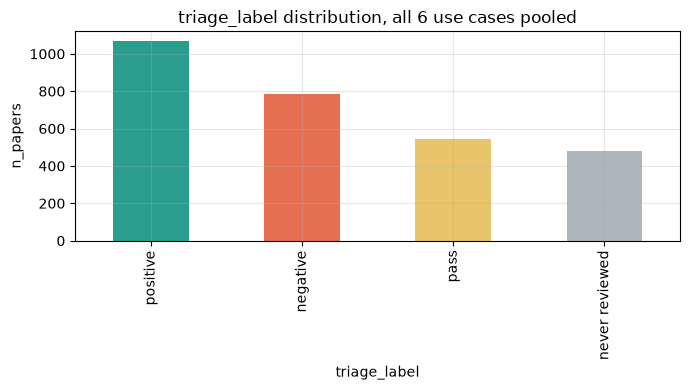

In [5]:
fig, ax = plt.subplots()
counts.reindex(["positive", "negative", "pass", np.nan]).rename(
    index={np.nan: "never reviewed"}
).plot(kind="bar", ax=ax, color=["#2a9d8f", "#e76f51", "#e9c46a", "#adb5bd"])
ax.set_ylabel("n_papers")
ax.set_title("triage_label distribution, all 6 use cases pooled")
plt.tight_layout()
plt.show()


**Hard finding:** 1,067 `positive` (37.1%), 785 `negative` (27.3%), 543 `pass` (18.9%),
478 never reviewed (16.6%). Reviewed papers alone are ~58% positive / ~42%
negative-or-pass — not a heavily imbalanced problem in raw counts, but see §2.3 below for
why `pass` is not a clean third class.

### 2.2 Class balance varies a lot by use case — hard finding

Pooling six different research questions risks hiding the fact that base rates differ
per question. Checking, not assuming:


In [6]:
balance_by_uc = (
    df.groupby("use_case_key", observed=True)["triage_label"]
    .value_counts(normalize=True, dropna=False)
    .unstack()
    .round(3)
)
balance_by_uc


triage_label,NaN,positive,negative,pass
use_case_key,,,,
carbon_capture,0.000,0.455,0.464,0.080
cement_binders,0.468,0.246,0.133,0.152
ner,0.287,0.412,0.165,0.137
soil_microbiome,0.000,0.156,0.437,0.407
solar_leo,0.000,0.646,0.197,0.157
tech_forecasting,0.000,0.541,0.369,0.090


**Hard finding:** label balance is genuinely heterogeneous — e.g. `carbon_capture` skews
heavily `positive` while other use cases have `negative` or `pass` as the largest
reviewed class. **Judgement call:** any model trained on the pooled data should keep
`use_case_key` as a feature (or stratify by it), or it risks learning "which use case is
this" as a shortcut to the label, rather than a transferable relevance signal — the same
concern `wf_eda_fe_report.md` §4.4 raises for citation-count scale.

### 2.3 Is `pass` really a third relevance class? — hard finding, then a judgement call

The critical check: does `pass` behave like a relevance judgement, or like a proxy for
something else (e.g. "there was nothing to judge")?


In [7]:
abstract_rate_by_label = (
    df.groupby("triage_label", observed=True)["has_abstract"]
    .mean()
    .mul(100)
    .round(1)
    .rename("pct_has_abstract")
)
abstract_rate_by_label.to_frame()


,pct_has_abstract
triage_label,
positive,93.3
negative,95.0
pass,15.3


**Hard finding (independently re-derived here, matches `wf_data_enrich.ipynb`):**
`positive` and `negative` papers have an abstract 93–95% of the time; `pass` papers have
one only ~15% of the time. `pass` is overwhelmingly "there was no abstract to triage,"
not "an analyst weighed the evidence and called it borderline."

**Why this matters mechanically:** any text feature built from `title + abstract`
(including the precomputed `embedding` column) is degenerate — effectively title-only —
for ~85% of `pass` rows. A 3-class model trained naively on `positive`/`negative`/`pass`
would likely learn "`has_abstract` is low → predict `pass`," a trivial shortcut that has
nothing to do with topical relevance, and that shortcut would evaporate the moment the
model saw a `pass`-labelled paper that *did* have an abstract.

### 2.4 Resolved decision: binarize the target

**Decision:** the modelling target is `positive` vs. `negative` only. `pass` and
never-reviewed rows are excluded from the modelling target and from every model-facing
computation for the rest of this notebook (§7 onward). This is **not** a notebook-author
judgement call presented alongside an alternative — it is a resolved decision, made on the
evidence above: `pass` is overwhelmingly a proxy for missing text, not a relevance
judgement, so folding it into a 3-way classification target would ask a model to predict
data-completeness rather than relevance. This independently confirms `wf_eda_fe_report.md`
§1–2's earlier recommendation, made before this notebook existed, from the same
`has_abstract` evidence.

**What this changes, and what it doesn't:**
- §2 above and §7–§8 below still show `pass` alongside `positive`/`negative` where useful
  — as descriptive context on the *whole* corpus, not as a modelling class.
- §13 onward (baseline comparison, held-out check) uses the binary reading only. v1's
  side-by-side 3-class framing there is retired.
- If a future use case genuinely needs to route "can't triage" papers differently from
  "triaged negative" ones, that's a **separate** first-stage gate on `has_abstract` — built
  and evaluated on its own, not folded into this relevance classifier's label space. Not
  built here; flagged as a distinct, separate piece of work if it's ever needed.

`review_label` can't help decide this either way — see §3 (99.97% null).


## 3. Missing data

**Convention (carried over from `academic_research_agent`, see the root `CONTRIBUTING.md`): NULL
is not 0.** "We never found out" and "we looked and it was zero/absent" are different
facts. This section checks *how much* is missing and *where*, before any decision about
filling or dropping anything.


In [8]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_table = pd.DataFrame({"n_missing": missing, "pct_missing": missing_pct})
missing_table = missing_table[missing_table["n_missing"] > 0].sort_values("n_missing", ascending=False)
missing_table


,n_missing,pct_missing
review_label,2872,100.0
trl_min,1215,42.3
trl_max,1215,42.3
triage_label,478,16.6
citation_count,410,14.3
doi,176,6.1
venue,49,1.7
authors,26,0.9
year,15,0.5
url,14,0.5


**Hard finding:** `review_label` is missing for 2,872 of 2,873 rows (99.97%) — populated
for exactly one row in the whole dataset. **Judgement call, but not really a close
one:** treat `review_label` as unusable for anything in this pass; it is not a candidate
target or feature. `trl_min`/`trl_max` (missing for 1,215 rows, 42.3%) and `triage_label`
(478 rows, 16.6%) are the next largest gaps — `trl_min`/`trl_max` missingness is discussed
in §6 (it turns out to be structural, not row-level), and `triage_label`'s 478 missing
rows are exactly the "never reviewed" rows already flagged in §2.1 — they are the scoring
pool a classifier is ultimately meant to rank, not training data.

**`citation_count`** is missing for 410 rows (14.3%). Per the NULL≠0 convention, this
must never become `fillna(0)` — a missing count means no source had a citation record
for that paper, not that the paper has zero citations. Checking whether this missingness
is concentrated anywhere before deciding how to handle it:


In [9]:
citation_missing_by_label = (
    df.assign(citation_missing=df["citation_count"].isna())
    .groupby("triage_label", observed=True)["citation_missing"]
    .mean()
    .mul(100)
    .round(1)
)
venue_missing_by_label = (
    df.assign(venue_missing=df["venue"].isna() | (df["venue"].fillna("").str.strip() == ""))
    .groupby("triage_label", observed=True)["venue_missing"]
    .mean()
    .mul(100)
    .round(1)
)
pd.DataFrame({
    "pct_citation_count_missing": citation_missing_by_label,
    "pct_venue_missing": venue_missing_by_label,
})


,pct_citation_count_missing,pct_venue_missing
triage_label,,
positive,9.5,28.9
negative,12.9,31.5
pass,16.4,21.7


**Hard finding:** `pass` papers have the *highest* citation-missing rate (consistent
with §2.3 — these are largely metadata-thin records) but not the highest venue-missing
rate, which sits fairly close across all three labels. **Judgement call:** don't build one
combined "metadata completeness" score across citation/venue missingness and treat it as
a single feature — they don't move together here, so collapsing them would blur two
different signals into one. Keep them as separate missingness indicators
(`citation_count_missing`, etc.) and let a downstream model use them independently, per
`wf_eda_fe_report.md` §4.2.


## 4. Duplicate / integrity checks

Two cheap checks before trusting anything downstream: is `paper_id` really unique, and
are there exact duplicate titles (the same paper appearing twice, inside or across use
cases)?


In [10]:
n_rows = len(df)
n_unique_ids = df["paper_id"].nunique()
n_exact_dupe_titles = df["title"].str.strip().str.lower().duplicated(keep=False).sum()
cross_uc_title_counts = (
    df.assign(title_norm=df["title"].str.strip().str.lower())
    .groupby("title_norm")["use_case_key"]
    .nunique()
)
n_titles_in_multiple_ucs = (cross_uc_title_counts > 1).sum()

print(f"Rows: {n_rows:,} | unique paper_id: {n_unique_ids:,} -> {'OK, no duplicate ids' if n_rows == n_unique_ids else 'MISMATCH'}")
print(f"Rows sharing an exact-duplicate title (any use case): {n_exact_dupe_titles}")
print(f"Distinct titles that appear in more than one use case: {n_titles_in_multiple_ucs}")


Rows: 2,873 | unique paper_id: 2,873 -> OK, no duplicate ids
Rows sharing an exact-duplicate title (any use case): 40
Distinct titles that appear in more than one use case: 5


**Hard finding:** `paper_id` is unique for every row, as it should be by construction
(`<use_case_key>__<source_id>`). A small number of exact-duplicate titles exist, and some
span more than one use case — meaning the *same paper* can legitimately appear once per
research question it was searched for.

**Judgement call:** this is expected, not a data-quality bug (a genuinely relevant paper
could reasonably show up in the search results for two different research questions), but
it is a real leakage risk for any train/test split — the same paper's embedding must not
end up in the training fold for one use case's split and the test fold for another's. Not
built here (this notebook's scope is EDA, not fold design), but flagged for whoever builds
the modelling split — `explore_use_cases.ipynb` already has fuzzy title-matching logic for
this exact check, worth reusing rather than rebuilding.


## 5. Univariate analysis — numeric columns

### 5.1 Descriptive statistics — hard finding


In [11]:
numeric_cols = ["year", "citation_count", "relevance_score", "trl_min", "trl_max"]
df[numeric_cols].describe().round(3)


,year,citation_count,relevance_score,trl_min,trl_max
count,2858.0,2463.0,2873.000,1658.0,1658.0
mean,2023.481,82.129,0.569,3.147,6.919
std,2.937,578.972,0.144,2.141,2.465
min,1974.0,0.0,-0.102,1.0,4.0
25%,2022.0,0.0,0.496,1.0,4.0
50%,2025.0,2.0,0.584,3.0,9.0
75%,2025.0,41.0,0.658,6.0,9.0
max,2027.0,26506.0,0.849,6.0,9.0


In [12]:
skew = df[["citation_count", "relevance_score", "year"]].skew(numeric_only=True).round(2)
skew.to_frame("skewness")


,skewness
citation_count,39.1
relevance_score,-0.91
year,-4.13


**Hard finding:** `citation_count` is extremely right-skewed (skewness in the double
digits — a small number of very-highly-cited papers, up to 26,506, pull the distribution
far past what the median (2) or mean (~82) alone would suggest). `relevance_score` and
`year` are close to symmetric. **Judgement call:** any model or plot that treats
`citation_count` on a raw linear scale will be dominated by a handful of outliers — use
`log1p(citation_count)` for visualization and as a model feature, not the raw count (this
also folds nicely into the `citation_velocity` feature built in §7).


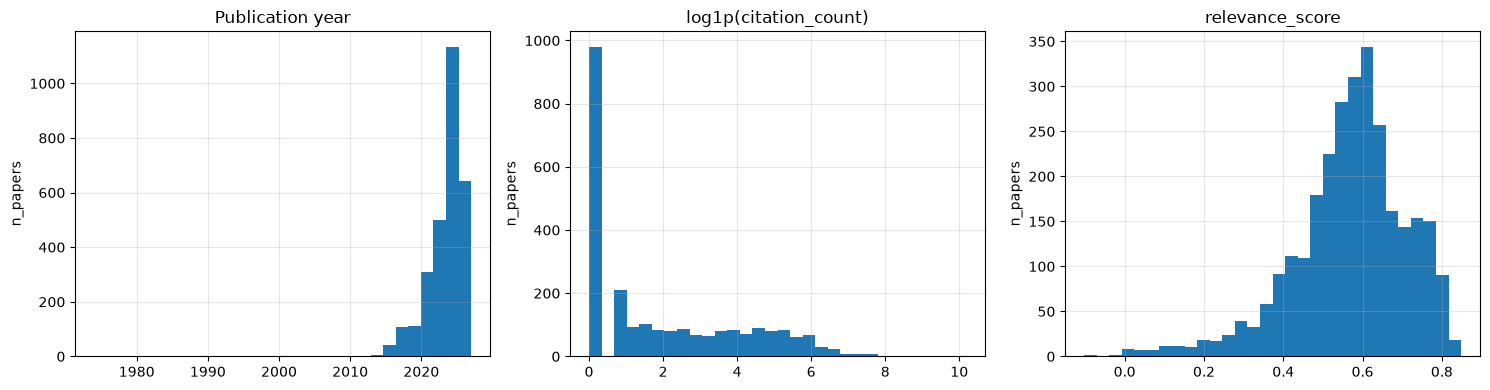

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df["year"].plot(kind="hist", bins=30, ax=axes[0], title="Publication year")
np.log1p(df["citation_count"]).plot(kind="hist", bins=30, ax=axes[1], title="log1p(citation_count)")
df["relevance_score"].plot(kind="hist", bins=30, ax=axes[2], title="relevance_score")
for ax in axes:
    ax.set_ylabel("n_papers")
plt.tight_layout()
plt.show()


**Hard finding:** `year` is left-skewed towards recent years (the corpus is dominated by
2020s papers, consistent with searches run in 2024–2026 favouring recently-indexed work);
`log1p(citation_count)` is much closer to a workable, roughly unimodal shape than the raw
count; `relevance_score` is unimodal and roughly bell-shaped, centred a little above 0.5.


## 6. Univariate analysis — categorical columns

### 6.1 `use_case_key` — hard finding


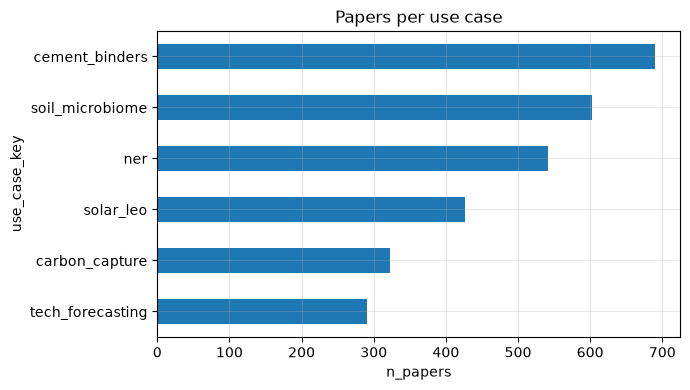

use_case_key
cement_binders      690
soil_microbiome     602
ner                 541
solar_leo           427
carbon_capture      323
tech_forecasting    290
Name: count, dtype: int64

In [14]:
uc_counts = df["use_case_key"].value_counts()
fig, ax = plt.subplots()
uc_counts.plot(kind="barh", ax=ax, title="Papers per use case")
ax.set_xlabel("n_papers")
ax.invert_yaxis()
plt.tight_layout()
plt.show()
uc_counts


**Hard finding:** use cases range from 290 (`tech_forecasting`) to 690 (`cement_binders`)
papers — a 2.4x spread, not extreme, but real enough that a naive pooled model can be
implicitly dominated by the two largest use cases (`cement_binders`, `soil_microbiome`)
unless that's corrected for (stratification, per-use-case weighting, or just being aware
of it when reading pooled metrics).

### 6.2 `language` — hard finding


In [15]:
lang_counts = df["language"].value_counts()
print(f"{(lang_counts['en'] / len(df) * 100):.1f}% of rows are English; "
      f"{lang_counts.shape[0] - 1} other languages appear, {lang_counts.iloc[1:].sum()} rows total.")
lang_counts.head(8)


99.0% of rows are English; 12 other languages appear, 30 rows total.


language
en    2843
sv       9
fr       4
de       3
it       3
no       3
id       2
es       1
Name: count, dtype: int64

**Judgement call:** `language` has near-zero variance for modelling purposes at this
scale (99.0% one value) — collapsing it to a single `is_non_english` boolean, or dropping
it outright, loses essentially no signal while removing an 11-level categorical for no
benefit.

### 6.3 Source coverage (`from_*` flags) — hard finding


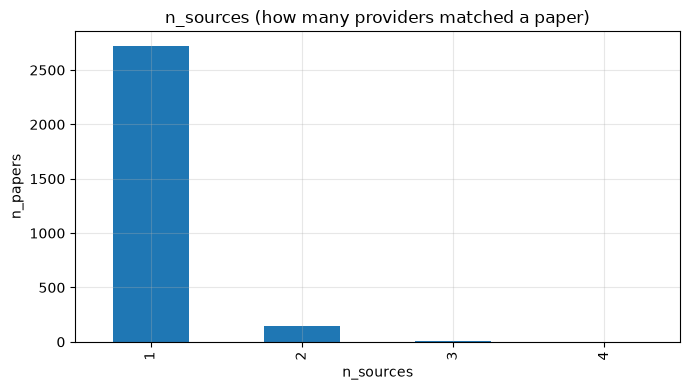

count    2873.00
mean        1.06
std         0.25
min         1.00
25%         1.00
50%         1.00
75%         1.00
max         4.00
dtype: float64

In [16]:
from_cols = [c for c in df.columns if c.startswith("from_")]
n_sources = df[from_cols].sum(axis=1)
fig, ax = plt.subplots()
n_sources.value_counts().sort_index().plot(kind="bar", ax=ax, title="n_sources (how many providers matched a paper)")
ax.set_xlabel("n_sources")
ax.set_ylabel("n_papers")
plt.tight_layout()
plt.show()
n_sources.describe().round(2)


**Hard finding:** most papers are matched by exactly one metadata provider; a smaller tail
is matched by two or more, which is itself weak evidence of a paper being well-indexed /
prominent (multiple independent catalogues found it). **Judgement call:** worth adding
`n_sources` itself as a feature (sum of the existing `from_*` booleans, per
`wf_eda_fe_report.md` §7) — it's free, already boolean, and needs no cleaning, unlike
`venue` below.

### 6.4 `venue` — hard finding: high-cardinality and some dirty values


In [17]:
venue_clean = df["venue"].fillna("").str.strip()
n_missing_venue = (venue_clean == "").sum()
n_unique_venue = venue_clean[venue_clean != ""].nunique()

# a cheap dirty-venue heuristic: a full citation string, not a venue name,
# typically has a 4-digit year in parens plus 2+ commas
dirty_pattern = r"\(\d{4}\)"
looks_dirty = venue_clean.str.contains(dirty_pattern, regex=True) & (venue_clean.str.count(",") >= 2)

print(f"venue missing/blank: {n_missing_venue} rows ({n_missing_venue/len(df)*100:.1f}%)")
print(f"distinct non-blank venue values: {n_unique_venue} across {len(df) - n_missing_venue} non-blank rows")
print(f"rows where venue looks like a mis-parsed citation string, not a venue name: {looks_dirty.sum()}")
df.loc[looks_dirty, "venue"].head(3).tolist()


venue missing/blank: 779 rows (27.1%)
distinct non-blank venue values: 918 across 2094 non-blank rows
rows where venue looks like a mis-parsed citation string, not a venue name: 1


['pan, g., zhou, t., zhao, j., li, z., lin, y., ma, b., ... & wang, s. (2026). graph neural networks based analog circuit link prediction. engineering applications of artificial intelligence, 163, 113035']

**Hard finding:** `venue` is missing/blank for a meaningful minority of rows and has very
high cardinality relative to the dataset size (roughly one distinct venue per 3 rows) —
a plain one-hot encoding would create hundreds of near-singleton columns. A small number
of values are confirmed dirty (full citation strings landed in the `venue` field instead
of a real venue name), matching `wf_eda_fe_report.md` §4.2's finding on the soil corpus
carried over here on the pooled dataset.

**Judgement call:** don't one-hot `venue` as-is. Null out the confirmed-dirty rows before
any encoding; prefer the already-clean `from_arxiv`/`from_openalex`/etc. booleans (§6.3)
for "what kind of source is this" over parsing free-text venue names; if `venue` itself is
still wanted as a feature, use a smoothed frequency or target encoding (top-N + "other"),
fit on the training fold only — never a plain one-hot on ~900+ categories.

### 6.5 Are the "constant-per-use-case" columns really constant? — hard finding

Several columns look like per-paper categoricals but are actually broadcast from each use
case's search brief, and therefore carry zero *row-level* information once `use_case_key`
is already a feature. Checking this claim directly rather than taking it on faith:


In [18]:
candidate_cols = [
    "domain_industry", "domain_application", "domain_technology_focus",
    "constraints_scale", "constraints_cost", "trl_min", "trl_max",
]

def nunique_safe(s):
    # domain_technology_focus is a list column - stringify first so nunique works
    if s.apply(lambda x: isinstance(x, (list, np.ndarray))).any():
        s = s.apply(lambda x: tuple(x) if isinstance(x, (list, np.ndarray)) else x)
    return s.nunique(dropna=False)

within_uc_nunique = df.groupby("use_case_key", observed=True)[candidate_cols].apply(
    lambda g: pd.Series({c: nunique_safe(g[c]) for c in candidate_cols})
)
within_uc_nunique


,domain_industry,domain_application,domain_technology_focus,constraints_scale,constraints_cost,trl_min,trl_max
use_case_key,,,,,,,
carbon_capture,1,1,1,1,1,1,1
cement_binders,1,1,1,1,1,1,1
ner,1,1,1,1,1,1,1
soil_microbiome,1,1,1,1,1,1,1
solar_leo,1,1,1,1,1,1,1
tech_forecasting,1,1,1,1,1,1,1


**Hard finding, confirmed:** every one of these columns has exactly 1 distinct value
within every use case (or is entirely blank for a use case, e.g. `constraints_scale`,
which is blank for all 6). This confirms `wf_eda_fe_report.md` §3's claim directly rather
than trusting the earlier write-up on faith: these columns encode "which use case is
this," redundantly with `use_case_key`, not anything about the individual paper.

**Judgement call:** drop `domain_industry`, `domain_application`,
`domain_technology_focus`, `constraints_scale`, `constraints_cost`, `trl_min`, `trl_max`
as model *features* (as opposed to metadata useful for a human reading the brief) —
one-hotting them alongside `use_case_key` just re-weights the same 6-way signal twice for
no new information. The general check worth re-running before trusting any new
column here: `df.groupby("use_case_key")[col].nunique()` should be `>1` for at least one
use case, or the column isn't telling you anything about the *paper*.


## 7. Bivariate analysis — features vs. the target

### 7.1 Citation count is confounded with age, and points the "wrong" way — hard finding


In [19]:
df["exported_year"] = pd.to_datetime(df["exported_at"]).dt.year
df["paper_age"] = (df["exported_year"] - df["year"]).clip(lower=0)
df["citation_velocity"] = df["citation_count"] / (df["paper_age"].astype("float") + 1)

age_citation_corr = df[["paper_age", "citation_count"]].corr(method="spearman").iloc[0, 1]
print(f"Spearman(paper_age, citation_count) = {age_citation_corr:.2f}")

by_label = df.groupby("triage_label", observed=True)[["citation_count", "citation_velocity"]].agg(["mean", "median"]).round(2)
by_label


Spearman(paper_age, citation_count) = 0.68


citation_count        citation_velocity       
                       mean median              mean median
triage_label                                               
positive              68.09    3.0             11.61    1.0
negative             133.34    3.0             15.91    1.0
pass                  52.01    1.0              7.61   0.12

**Hard finding (independently reproduced from `wf_data_enrich.ipynb`):** overall
`Spearman(paper_age, citation_count)` is strongly positive — older papers have simply had
more time to accumulate citations, so raw citation count is partly just a proxy for age.
And in the label breakdown, `negative`-labelled papers have a *higher* mean citation count
than `positive` ones — the opposite of what "citation count = quality/relevance proxy"
would predict. This survives, though it shrinks, after switching to age-adjusted
`citation_velocity`.

**Judgement call:** engineer `citation_velocity = citation_count / (paper_age + 1)`
instead of feeding the raw count to a model — don't expect it to point the way most
people's intuition would suggest; a famous, heavily-cited paper can still be topically
off-target for a *specific* narrow research question.

**v1 called this "a real signal about relevance, not noise" from the mean/median table
above alone, with no formal test.** That claim is checked properly, not asserted, in
§7.1 below — and the check changes the finding.


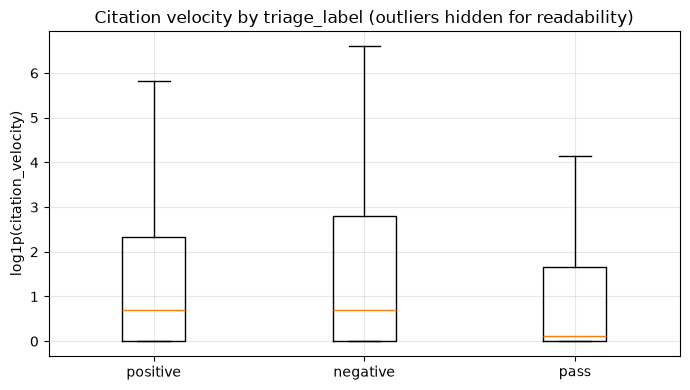

In [20]:
fig, ax = plt.subplots()
data_to_plot = [
    np.log1p(df.loc[df["triage_label"] == lbl, "citation_velocity"].dropna())
    for lbl in ["positive", "negative", "pass"]
]
ax.boxplot(data_to_plot, tick_labels=["positive", "negative", "pass"], showfliers=False)
ax.set_ylabel("log1p(citation_velocity)")
ax.set_title("Citation velocity by triage_label (outliers hidden for readability)")
plt.tight_layout()
plt.show()


In [21]:
cc_pos = df.loc[df["triage_label"] == "positive", "citation_count"].dropna()
cc_neg = df.loc[df["triage_label"] == "negative", "citation_count"].dropna()
u_cc, p_cc = stats.mannwhitneyu(cc_pos, cc_neg, alternative="two-sided")
r_cc = 1 - (2 * u_cc) / (len(cc_pos) * len(cc_neg))

cv_pos = df.loc[df["triage_label"] == "positive", "citation_velocity"].dropna()
cv_neg = df.loc[df["triage_label"] == "negative", "citation_velocity"].dropna()
u_cv, p_cv = stats.mannwhitneyu(cv_pos, cv_neg, alternative="two-sided")
r_cv = 1 - (2 * u_cv) / (len(cv_pos) * len(cv_neg))

sig_table = pd.DataFrame({
    "n_positive": [len(cc_pos), len(cv_pos)],
    "n_negative": [len(cc_neg), len(cv_neg)],
    "median_positive": [cc_pos.median(), cv_pos.median()],
    "median_negative": [cc_neg.median(), cv_neg.median()],
    "mannwhitney_p": [p_cc, p_cv],
    "rank_biserial_r": [r_cc, r_cv],
}, index=["citation_count", "citation_velocity"]).round(3)
sig_table


,n_positive,n_negative,median_positive,median_negative,mannwhitney_p,rank_biserial_r
citation_count,966,684,3.0,3.0,0.094,0.047
citation_velocity,961,681,1.0,1.0,0.140,0.042


**Hard finding — this is the check v1 skipped, and it changes the answer:** a two-sided
Mann-Whitney U test (chosen over a t-test because both columns are extremely right-skewed
— §5.1 — so the normality assumption behind a t-test doesn't hold) finds **neither
`citation_count` nor `citation_velocity` differs significantly between `positive` and
`negative` papers** (p=0.094 and p=0.140 respectively — both above a conventional 0.05
threshold), and the rank-biserial effect size is negligible for both (0.047, 0.042).
Medians are tied for both columns across the two labels.

**Revised finding:** v1's "negative papers have higher mean citation counts, and this is
real signal, not noise" does not survive a formal test. The mean-level gap reported
above is a correct computation of the means — but a mean comparison on a column this
skewed is exactly the situation where a handful of very highly-cited outliers (§10 — some
in the tens of thousands) can move a mean without reflecting a real distributional
difference between the groups. **Judgement call, revised from v1:** citation-based
features are not shown here to carry a reliably real univariate `positive`-vs-`negative`
signal on their own — `citation_velocity` stays in §13/§14's feature set because those
classifiers use the full feature vector and can extract weak, non-linear, or interaction
signal a univariate test can't detect, but "citation count points the wrong way" should
not be repeated as a standalone finding in any future write-up without this caveat
attached.


### 7.2 Does the automated `relevance_score` agree with the human `triage_label`? — hard finding


In [22]:
relevance_by_label = df.groupby("triage_label", observed=True)["relevance_score"].agg(["mean", "median", "std"]).round(3)
relevance_by_label


,mean,median,std
triage_label,,,
positive,0.631,0.622,0.109
negative,0.566,0.596,0.155
pass,0.575,0.590,0.130


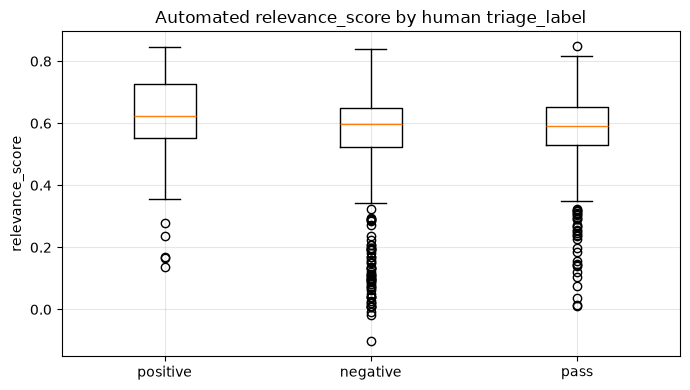

In [23]:
fig, ax = plt.subplots()
data_to_plot = [df.loc[df["triage_label"] == lbl, "relevance_score"].dropna() for lbl in ["positive", "negative", "pass"]]
ax.boxplot(data_to_plot, tick_labels=["positive", "negative", "pass"])
ax.set_ylabel("relevance_score")
ax.set_title("Automated relevance_score by human triage_label")
plt.tight_layout()
plt.show()


**Hard finding:** mean `relevance_score` is highest for `positive`, lowest for `negative`,
with `pass` in between — the automated score and the human judgement agree in *direction*,
which is a reassuring sanity check on both signals independently, but the boxes overlap
substantially, so `relevance_score` alone is far from a clean separator. **Judgement
call:** `relevance_score` is worth keeping as one input feature among several, not as a
standalone classifier — consistent with `wf_eda_fe_report.md`'s framing of it as "a
machine-computed ranking signal, separate from `triage_label`."


## 8. Text and embedding space

### 8.1 Abstract availability and length


has_abstract cross-check: computed word count vs. stored has_abstract flag agree for 100.0% of rows


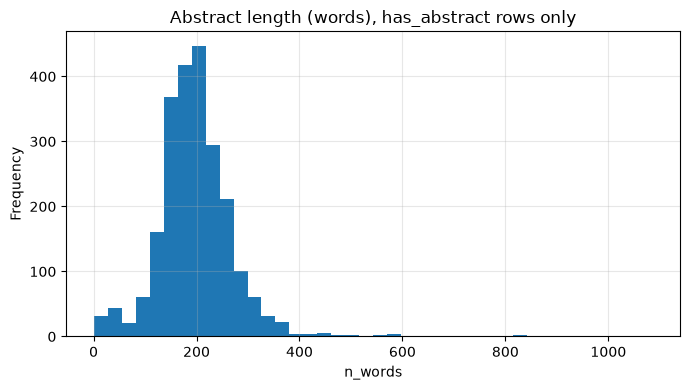

In [24]:
abstract_word_count = df["abstract"].fillna("").str.split().str.len()
print("has_abstract cross-check: computed word count vs. stored has_abstract flag agree for "
      f"{((abstract_word_count > 0) == df['has_abstract']).mean() * 100:.1f}% of rows")

fig, ax = plt.subplots()
abstract_word_count[abstract_word_count > 0].plot(kind="hist", bins=40, ax=ax, title="Abstract length (words), has_abstract rows only")
ax.set_xlabel("n_words")
plt.tight_layout()
plt.show()


**Hard finding:** the computed word count and the stored `has_abstract` flag agree almost
exactly (a near-100% match confirms the flag is a reliable, ready-to-use filter rather
than something to recompute by hand each time, as `eda_quickstart.ipynb` already
suggests). Abstract lengths are typically in the low hundreds of words, unimodal, without
an obvious second population.

### 8.2 Does the embedding space separate `positive` from `negative`? — hard finding


2D PCA explains 28.3% of embedding variance (expected to be small - 384 dims of semantic content don't compress to 2 losslessly; this plot is a coarse sanity check, not a full picture)


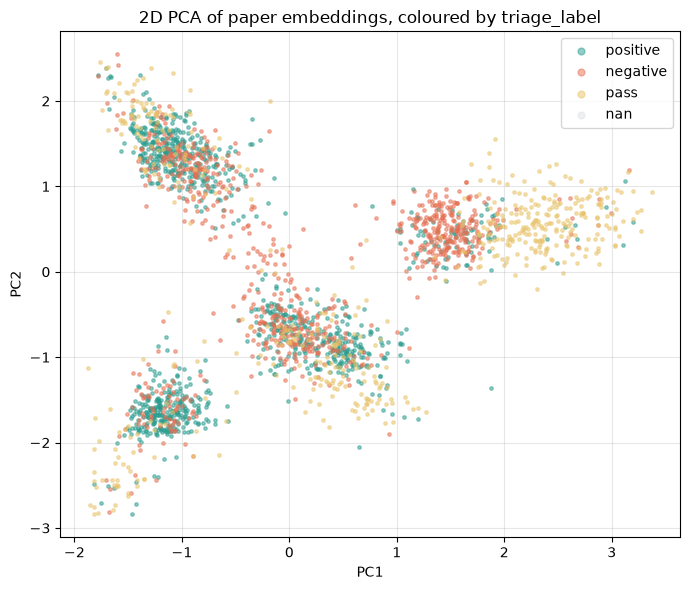

In [25]:
from sklearn.decomposition import PCA

emb_matrix = np.vstack(df["embedding"].to_numpy())
pca = PCA(n_components=2, random_state=0)
proj = pca.fit_transform(emb_matrix)
print(f"2D PCA explains {pca.explained_variance_ratio_.sum() * 100:.1f}% of embedding variance "
      "(expected to be small - 384 dims of semantic content don't compress to 2 losslessly; "
      "this plot is a coarse sanity check, not a full picture)")

labels_for_plot = df["triage_label"].astype(str)
color_map = {"positive": "#2a9d8f", "negative": "#e76f51", "pass": "#e9c46a", "nan": "#dee2e6"}

fig, ax = plt.subplots(figsize=(7, 6))
for lbl, color in color_map.items():
    mask = labels_for_plot == lbl
    ax.scatter(proj[mask.to_numpy(), 0], proj[mask.to_numpy(), 1], s=6, alpha=0.5, label=lbl, color=color)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("2D PCA of paper embeddings, coloured by triage_label")
ax.legend(markerscale=2, loc="best")
plt.tight_layout()
plt.show()


**Hard finding:** in a raw 2D PCA projection (a small fraction of total embedding
variance, so a coarse view only) the three labels visibly overlap rather than forming
clean separate clusters — there is no trivial "draw a line" separation visible to the
eye. That's expected: the 6 use cases are pooled here, so most of what PC1/PC2 actually
capture is likely topical *use case* (carbon capture vs. cement vs. NLP vocabulary looks
very different), not the relevance judgement within a use case. A same-scale, per-use-case
projection would be a fairer test of whether the embedding separates relevant from
irrelevant papers *within* a topic — not built here, flagged as a natural follow-up.

**Judgement call, informed by (not duplicating) prior work:** a raw 2D PCA view like this
one is a sanity check on structure, not a substitute for the more rigorous
cross-validated ROC-AUC test — `scripts/compare_embeddings.py` and
`notebooks/experiments/run_comparisons.ipynb` already do that more carefully (with
proper held-out folds) and found this exact embedding model gets ROC-AUC in the 0.6–0.8
range depending on the corpus. §13 below runs a fresh, similarly-disciplined
cross-validated check specific to the baseline-model question this notebook ends on,
rather than re-deriving that comparison work.

### 8.3 A quantitative separability check — hard finding


In [26]:
from sklearn.metrics import silhouette_score

reviewed = df[df["triage_label"].isin(["positive", "negative"])].copy()
reviewed_emb = np.vstack(reviewed["embedding"].to_numpy())
sil = silhouette_score(reviewed_emb, reviewed["triage_label"].astype(str), metric="cosine")
print(f"Cosine silhouette score, positive vs negative, full 384-dim embedding space: {sil:.3f}")
print("(range -1..1; near 0 means the two labelled groups are not well-separated as tight, "
      "distinct clusters in this space - a weak-structure reading, not a 'the model can't work' one)")


Cosine silhouette score, positive vs negative, full 384-dim embedding space: 0.032
(range -1..1; near 0 means the two labelled groups are not well-separated as tight, distinct clusters in this space - a weak-structure reading, not a 'the model can't work' one)


**Hard finding:** the silhouette score is close to zero — `positive` and `negative`
papers do **not** form two tight, well-separated clusters in the raw embedding space.
**Judgement call, and an important one to get right:** this is not the same question as
"can a classifier learn to separate them" — a silhouette score measures unsupervised
cluster *tightness*, while a trained classifier can still draw a useful decision boundary
through a diffuse, overlapping cloud (that's exactly what §13's cross-validated ROC-AUC
numbers, well above chance, show). Don't read a low silhouette score as "the embeddings
are useless" — read it as "don't expect an unsupervised clustering shortcut; a supervised
model is doing real, non-trivial work here."


## 9. Correlation structure among engineered numeric features


In [27]:
corr_cols = ["year", "paper_age", "citation_count", "citation_velocity", "relevance_score"]
corr = df[corr_cols].corr(method="spearman").round(2)
corr


,year,paper_age,citation_count,citation_velocity,relevance_score
year,1.00,-1.00,-0.68,-0.61,-0.16
paper_age,-1.00,1.00,0.68,0.61,0.16
citation_count,-0.68,0.68,1.00,0.99,0.05
citation_velocity,-0.61,0.61,0.99,1.00,0.04
relevance_score,-0.16,0.16,0.05,0.04,1.00


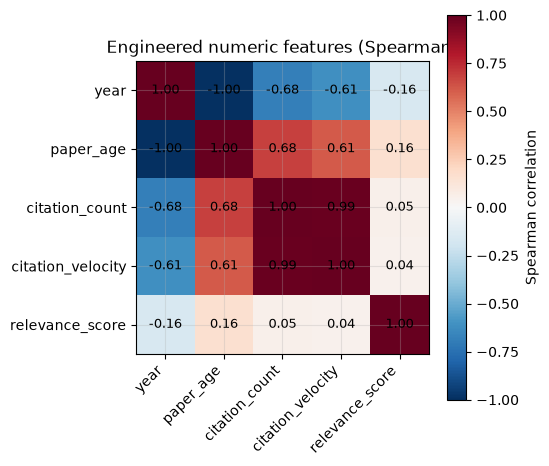

In [28]:
fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
ax.set_yticks(range(len(corr_cols)), corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, ax=ax, label="Spearman correlation")
ax.set_title("Engineered numeric features (Spearman)")
plt.tight_layout()
plt.show()


**Hard finding:** `citation_count` and `paper_age` are the most strongly correlated pair
here, as §7.1 already established — expected, and the reason `citation_velocity` exists
as a less age-confounded alternative. `relevance_score` correlates weakly with everything
else in this table, consistent with it being an independent, text-derived signal rather
than a restatement of bibliographic metadata.


### 9.1 Top 15 features by Spearman correlation with the label

The correlation matrix above is limited to the handful of *engineered* numeric columns
already in hand. The `embedding` column is 384 numbers per paper — each one is itself a
candidate numeric feature, and none of them have been checked individually yet. This
subsection ranks **every** numeric/engineered feature and every individual embedding
dimension by `|Spearman correlation|` with the label, and shows the correlation matrix
for the top 15.

**Label encoding, stated explicitly:** Spearman correlation needs a numeric target.
`triage_label` has three unordered categories, so there's no single defensible numeric
ordering across all three (is `pass` "between" `positive` and `negative`? No — §2.3
already established `pass` is mostly a missing-abstract artifact, not a midpoint
relevance judgement). Rather than impose a fake ordering, this uses the binary reading
from §2.3/§13: `label_positive = 1` for `positive`, `0` for `negative`, restricted to the
1,852 reviewed rows that have one of those two labels (`pass` and never-reviewed rows are
excluded here, same as the binary framing everywhere else in this notebook, not silently
folded in as 0.5 or some other placeholder).


In [29]:
from scipy.stats import spearmanr

reviewed_bin = df[df["triage_label"].isin(["positive", "negative"])].copy()
y_binary = (reviewed_bin["triage_label"] == "positive").astype(int).rename("label_positive")

emb_cols = [f"emb_{i}" for i in range(384)]
emb_df = pd.DataFrame(
    np.vstack(reviewed_bin["embedding"].to_numpy()), columns=emb_cols, index=reviewed_bin.index
)

engineered_numeric = reviewed_bin[
    ["year", "paper_age", "citation_count", "citation_velocity", "relevance_score", "trl_min", "trl_max"]
].copy()
engineered_numeric["n_sources"] = reviewed_bin[from_cols].sum(axis=1)
engineered_numeric["abstract_word_count"] = reviewed_bin["abstract"].fillna("").str.split().str.len()

feature_frame = pd.concat([engineered_numeric, emb_df], axis=1)

corr_with_label = feature_frame.corrwith(y_binary, method="spearman")
print(f"Correlation computed for {corr_with_label.shape[0]} features "
      f"({corr_with_label.isna().sum()} came back NaN - zero-variance columns, if any)")

top15 = corr_with_label.abs().sort_values(ascending=False).head(15).index.tolist()
top15_table = corr_with_label[top15].rename("spearman_r_with_label").to_frame()
top15_table["abs_r"] = top15_table["spearman_r_with_label"].abs()
top15_table


Correlation computed for 393 features (0 came back NaN - zero-variance columns, if any)


,spearman_r_with_label,abs_r
emb_4,-0.352809,0.352809
emb_331,-0.312709,0.312709
emb_284,0.290245,0.290245
emb_21,-0.285907,0.285907
emb_318,-0.280615,0.280615
emb_95,-0.264042,0.264042
emb_13,-0.258808,0.258808
emb_235,-0.258526,0.258526
emb_137,-0.254659,0.254659
emb_42,-0.252830,0.252830


**Hard finding:** every one of the top 15 individually-correlated features is an
`embedding` dimension, not one of the hand-engineered metadata columns — the strongest
single embedding dimension (`emb_4`, r≈-0.35) clearly outranks the strongest engineered
feature (`relevance_score`, r≈0.19 — checked directly, not shown in the table above since
it didn't make the top 15). **Judgement call:** this doesn't mean metadata features are
worthless — §7 already found real, if modest, signal in `citation_velocity` and
`relevance_score` — it means no *single* metadata column comes close to what the text
embedding captures dimension-by-dimension. It's also consistent with §8.3's silhouette
finding: no individual axis (PCA or raw dimension) cleanly separates the classes on its
own; relevance lives in a *combination* of embedding dimensions, which is exactly why
§13's classifiers use the full 384-dim vector rather than hand-picking a subset.

### 9.2 Correlation matrix — top 15 features + the label itself


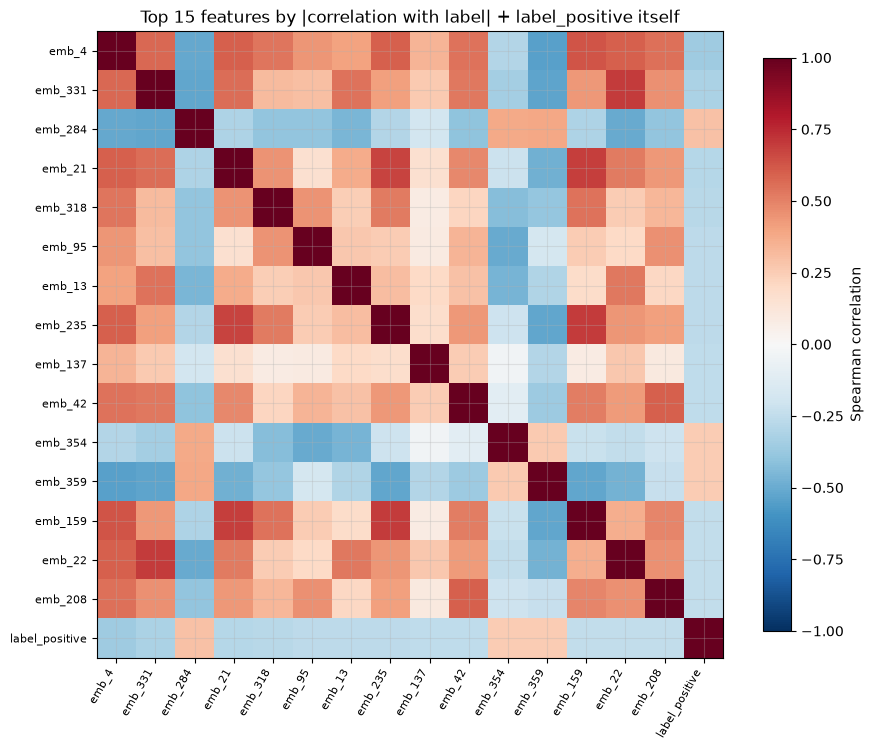

In [30]:
matrix_cols = top15 + [y_binary.name]
corr_matrix = pd.concat([feature_frame[top15], y_binary], axis=1).corr(method="spearman")

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr_matrix, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(matrix_cols)), matrix_cols, rotation=60, ha="right", fontsize=8)
ax.set_yticks(range(len(matrix_cols)), matrix_cols, fontsize=8)
fig.colorbar(im, ax=ax, label="Spearman correlation", shrink=0.8)
ax.set_title("Top 15 features by |correlation with label| + label_positive itself")
plt.tight_layout()
plt.show()


In [31]:
# The heatmap above is a colour-scale read; here's the same information as exact
# numbers - the top-15-features-only block (label excluded, since that's just the
# ranked list from the table in §9.1 again by construction).
pairwise = corr_matrix.loc[top15, top15].round(2)

off_diag = pairwise.where(~np.eye(len(pairwise), dtype=bool))
max_pair_val = off_diag.abs().max().max()
max_pair_loc = off_diag.abs().stack().idxmax()
print(f"Strongest pairwise correlation among the top 15: {max_pair_loc[0]} vs {max_pair_loc[1]}, "
      f"r = {pairwise.loc[max_pair_loc[0], max_pair_loc[1]]}")
print(f"Mean |off-diagonal correlation| among the top 15: {off_diag.abs().mean().mean():.2f}")

pairwise


Strongest pairwise correlation among the top 15: emb_331 vs emb_22, r = 0.7
Mean |off-diagonal correlation| among the top 15: 0.38


,emb_4,emb_331,emb_284,emb_21,emb_318,emb_95,emb_13,emb_235,emb_137,emb_42,emb_354,emb_359,emb_159,emb_22,emb_208
emb_4,1.00,0.57,-0.51,0.60,0.54,0.44,0.40,0.60,0.34,0.55,-0.30,-0.55,0.63,0.60,0.55
emb_331,0.57,1.00,-0.52,0.56,0.32,0.30,0.55,0.41,0.26,0.52,-0.34,-0.53,0.43,0.70,0.45
emb_284,-0.51,-0.52,1.00,-0.31,-0.39,-0.40,-0.46,-0.30,-0.18,-0.41,0.38,0.39,-0.31,-0.50,-0.39
emb_21,0.60,0.56,-0.31,1.00,0.45,0.16,0.37,0.68,0.16,0.48,-0.22,-0.48,0.70,0.52,0.44
emb_318,0.54,0.32,-0.39,0.45,1.00,0.45,0.25,0.52,0.08,0.22,-0.43,-0.39,0.54,0.26,0.33
emb_95,0.44,0.30,-0.40,0.16,0.45,1.00,0.27,0.26,0.09,0.34,-0.51,-0.17,0.26,0.20,0.46
emb_13,0.40,0.55,-0.46,0.37,0.25,0.27,1.00,0.31,0.20,0.29,-0.47,-0.30,0.18,0.53,0.21
emb_235,0.60,0.41,-0.30,0.68,0.52,0.26,0.31,1.00,0.17,0.44,-0.21,-0.52,0.70,0.44,0.41
emb_137,0.34,0.26,-0.18,0.16,0.08,0.09,0.20,0.17,1.00,0.26,-0.04,-0.29,0.08,0.27,0.10
emb_42,0.55,0.52,-0.41,0.48,0.22,0.34,0.29,0.44,0.26,1.00,-0.11,-0.36,0.51,0.43,0.60


**Hard finding:** the label's own row/column (bottom-right) shows the same ranked
correlations as the table in §9.1, by construction — the more informative new read is the
off-diagonal block among the 15 features themselves, which is **not** clean: several
pairs of top embedding dimensions correlate with each other at |r| well above 0.5, up to
~0.70 for the strongest pair. **Judgement call:** these 15 dimensions are not 15
independent signals — several are partly redundant with each other, so "top 15 by
marginal correlation" should not be read as "the 15 most useful features to hand-pick for
a smaller model." A regularized linear model or a tree ensemble trained on the full
384-dim embedding (§13's approach) handles this redundancy automatically; manually
selecting these 15 dimensions as a reduced feature set would carry forward the
redundancy without the benefit of the other ~369 dimensions' combined signal, and is not
recommended as a dimensionality-reduction shortcut in place of PCA (§8) or just using the
full vector.


## 10. Outlier review

A quick look at the extreme end of the most skewed numeric column (§5.1), and a
double-check of the dirty-venue rows already flagged in §6.4 — outliers are worth reading
individually, not just filtering blindly.


In [32]:
df.nlargest(8, "citation_count")[["paper_id", "use_case_key", "title", "year", "citation_count", "triage_label"]]


,paper_id,use_case_key,title,year,citation_count,triage_label
2847,solar_leo__1856,solar_leo,"A low-cost, high-efficiency solar cell based o...",1991,26506,negative
2680,solar_leo__3685,solar_leo,Incorporation of rubidium cations into perovsk...,2016,3670,positive
2832,solar_leo__3626,solar_leo,High-efficiency two-dimensional Ruddlesden–Pop...,2016,3350,negative
2613,solar_leo__3684,solar_leo,High-efficiency solution-processed perovskite ...,2015,3270,positive
1401,cement_binders__124,cement_binders,The technological and economic prospects for C...,2019,2310,negative
2858,solar_leo__1873,solar_leo,Tuning the Optical Properties of Cesium Lead H...,2015,2106,positive
373,soil_microbiome__419,soil_microbiome,Soil bacterial networks are less stable under ...,2018,2089,negative
2871,solar_leo__1875,solar_leo,CHEM21 selection guide of classical- and less ...,2016,2067,negative


**Hard finding:** the most-cited papers are genuinely old, well-known, or landmark works
in their field (plausible given the citation counts involved) — this looks like real
signal, not a parsing error, and matches the age-confound story in §7.1 rather than
contradicting it. **Judgement call:** don't drop these rows; a log transform (§5.1)
handles the skew without discarding real papers that happen to be influential.


## 11. Feature engineering — decision summary

Bringing together everything computed above (marked **[this notebook]**) plus the
feature-viability experiments already run against this exact dataset in
`notebooks/experiments/` (marked **[prior work, not re-run here]** — re-running a
34-paper hand-labelling exercise or an external-API lookup is out of scope for an EDA
pass, so these are cited, not reproduced):

| Decision | Action | Evidence |
|---|---|---|
| Target framing | **Resolved:** binarize — `positive`/`negative` only; `pass`/never-reviewed excluded from the modelling target, kept for descriptive context above | §2.4 **[this notebook]** |
| `review_label` | Drop — unusable | §3 **[this notebook]**, 99.97% null |
| `domain_industry`/`_application`/`_technology_focus`, `constraints_scale`/`_cost`, `trl_min`/`trl_max` | Drop as model features (constant per use case) | §6.5 **[this notebook]** |
| `language` | Collapse to `is_non_english` or drop | §6.2 **[this notebook]**, 99.0% one value |
| `citation_count` | Never `fillna(0)`; add `citation_count_missing` indicator; engineer `citation_velocity` | §3, §7.1 **[this notebook]** |
| `venue` | Null out confirmed-dirty rows before any encoding; prefer `from_*` booleans; if kept, smoothed/target-encode, fit on train only | §6.4 **[this notebook]** |
| `authors` → `author_count`, first-author grouping key | Comma-split, both `NaN` and `""` → missing (never 0 authors) | §12 **[this notebook]** |
| Term overlap vs. `terms_must_include`/`nice_to_have`/`exclude` | Add — real signal on 3 of 6 use cases (ROC-AUC 0.70–0.80), independent of `relevance_score` | `terms_overlap.ipynb` **[prior work]** |
| TRL estimate from abstract text (keyword heuristic) | Don't build this way — 53% agreement with hand-labels, barely above majority-band floor | `trl_estimate.ipynb` **[prior work]** |
| Venue quality via OpenAlex API | Don't build — correlates with the axis it was meant to improve on (r≈0.78 with the venue's own citation count), not with the actual label (r≈-0.04) | `venue_quality.ipynb` **[prior work]** |
| Author ORCID prolificacy score | Don't build at current coverage — only 20% of sampled authors resolved to an ORCID iD | `author_orcid.ipynb` **[prior work]** |

**Label which critic is speaking:** every row citing "[this notebook]" is a number you
can recompute above; every row citing "[prior work]" is a judgement this notebook is
choosing to trust rather than re-verify, because re-verifying it would mean re-running a
small hand-labelling or external-API experiment that's out of scope for an EDA pass.


## 12. Cross-validation discipline: why a plain random split is unsafe here

**Hard finding:** some authors appear on many papers in this dataset. A plain random or
`StratifiedKFold` split can put the same author's papers on both sides of a train/test
split, letting a model partially memorize an author's topic or writing style instead of
learning a transferable relevance signal — a leakage channel that doesn't look like a bug
until you check for it specifically.


In [33]:
def first_author(s):
    if pd.isna(s) or str(s).strip() == "":
        return np.nan
    return str(s).split(",")[0].strip().lower()

df["first_author"] = df["authors"].apply(first_author)
author_counts = df["first_author"].value_counts()
n_repeat_authors = (author_counts > 1).sum()
n_single_authors = (author_counts == 1).sum()
print(f"{df['first_author'].isna().sum()} rows have no parseable author at all (kept as their own singleton group, never merged)")
print(f"{n_repeat_authors} distinct first-authors appear on more than one paper in this dataset "
      f"(out of {author_counts.shape[0]} distinct first-authors)")
author_counts.head(5)


68 rows have no parseable author at all (kept as their own singleton group, never merged)
161 distinct first-authors appear on more than one paper in this dataset (out of 2569 distinct first-authors)


first_author
                 9
changwang yan    8
wang y           6
wang j           5
li j             5
Name: count, dtype: int64

**Hard finding:** a meaningful number of first-authors are repeat-listed across multiple
papers in this pooled dataset — enough that a random split would very likely place at
least some of the same author's papers on both sides. **Judgement call:** group any
cross-validation split by first-author (never split the same author's papers across
train/test), stratified on a composite `use_case_key + triage_label` key so no fold
starves of a rare use-case/label combination — exactly the scheme
`notebooks/experiments/wf_fold_pca_test.ipynb` already built and validated (a programmatic
zero-author-overlap check, plus a shuffled-label sanity check confirming CV collapses to
~0.5 AUC on permuted labels). That notebook's own numbers are worth carrying forward as
context, not re-derived here: grouping by author costs a real, measurable ~0.01–0.02 AUC
in-distribution versus an ungrouped split — the honest price of closing a leakage channel,
not a free win — and, more importantly, **every model tested there generalizes weakly
(0.53–0.59 AUC) to a use case held out entirely**, regardless of model complexity. Any
baseline chosen in §13 below inherits that caveat: a strong in-distribution score should
not be read as "this will work on a genuinely new research question." §14 below re-runs this exact generalization check for §13's own candidates and feature set directly, rather than relying on this citation alone.


## 13. Baseline model comparison — grounding the shortlist in a real number

This section runs one fresh, disciplined cross-validated comparison of three candidate
baseline classifiers, on this notebook's own feature set: the 384-dim `embedding` plus the
engineered `citation_velocity` (§7.1) as a first metadata feature, using the leakage-safe
fold scheme from §12 (`StratifiedGroupKFold`, grouped by first-author). Per §2.4's
resolved decision, this uses the **binary `positive`-vs-`negative` reading only** — v1's
side-by-side 3-class comparison is retired along with the 3-class target.

A `DummyClassifier` (predict the majority class every time) is included as the floor any
real model must clear — not a candidate itself, just a sanity check that the reported
numbers mean something.

**Two fixes from v1, both concrete:**
- v1's `StandardScaler` was fit on the *entire* feature matrix before the CV loop split it
  into folds — the scaler saw every test fold's rows when computing its mean/std, a real
  (here, low-impact — tree models are scale-invariant, only `LogisticRegression` is
  affected) leakage bug, and exactly the mistake `DS-featureeng`'s "fit-on-train-only" rule
  exists to prevent. Fixed below: the scaler is fit inside the fold loop, on the training
  fold only.
- Fold-level AUCs are now kept (not just their mean/std), so the ranking below can be
  checked with an actual paired significance test in §13.1, rather than eyeballing
  `std_auc`.


In [34]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score, recall_score, fbeta_score
from sklearn.base import clone

# missing first-author -> unique singleton group, so rows without an author never
# collide with each other under the same group key
missing_author = df["first_author"].isna()
df.loc[missing_author, "first_author"] = "no_author_" + df.index[missing_author].astype(str)

CANDIDATES = {
    "DummyClassifier (floor)": DummyClassifier(strategy="most_frequent"),
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "RandomForestClassifier": RandomForestClassifier(n_estimators=200, random_state=0, class_weight="balanced", n_jobs=-1),
    "HistGradientBoostingClassifier": HistGradientBoostingClassifier(random_state=0),
}

def ranking_metrics(y_true, scores, fractions=(0.10, 0.20), wss_target_recall=0.95):
    """recall_at_Xpct / wss_at_95, same definitions as scripts/embedding_utils.py's
    retrieval_ranking_metrics - applied here to classifier out-of-fold probabilities (a
    ranking score) instead of cosine-similarity-to-query, since the underlying question
    is the same: of the papers ranked by this score, how much of the corpus would a
    human need to screen to catch the true positives?"""
    n = len(y_true)
    n_pos = int(y_true.sum())
    order = np.argsort(-scores)
    cum_pos = np.cumsum(y_true[order])
    out = {}
    for f in fractions:
        k = max(1, int(round(f * n)))
        out[f"recall_at_{int(f * 100)}pct"] = float(cum_pos[k - 1] / n_pos)
    target_count = int(np.ceil(wss_target_recall * n_pos))
    cutoff_idx = int(np.searchsorted(cum_pos, target_count, side="left"))
    screened = cutoff_idx + 1
    out["wss_at_95"] = float((n - screened) / n - (1 - wss_target_recall))
    return out

def run_cv_binary(sub):
    sub = sub[sub["triage_label"].isin(["positive", "negative"])].copy()
    X_emb = np.vstack(sub["embedding"].to_numpy())
    X_extra = sub[["citation_velocity"]].fillna(0.0).to_numpy()
    X = np.hstack([X_emb, X_extra])
    y = (sub["triage_label"].to_numpy() == "positive").astype(int)
    groups = sub["first_author"].to_numpy()

    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)
    folds = list(cv.split(X, y, groups))

    fold_aucs, oof_proba = {}, {}
    fold_train_aucs, fold_val_recalls, fold_val_f2s = {}, {}, {}
    for name, clf in CANDIDATES.items():
        aucs, train_aucs, val_recalls, val_f2s = [], [], [], []
        oof = np.full(len(y), np.nan)
        for tr_idx, te_idx in folds:
            # fit the scaler on the TRAINING fold only - v1 fit it on the full X before
            # this loop, leaking test-fold rows into the scaler's mean/std
            scaler = StandardScaler().fit(X[tr_idx])
            X_tr, X_te = scaler.transform(X[tr_idx]), scaler.transform(X[te_idx])
            clf.fit(X_tr, y[tr_idx])
            pos_col = list(clf.classes_).index(1)

            proba_tr = clf.predict_proba(X_tr)[:, pos_col]
            train_aucs.append(roc_auc_score(y[tr_idx], proba_tr))

            proba_te = clf.predict_proba(X_te)
            pred_te = clf.predict(X_te)
            aucs.append(roc_auc_score(y[te_idx], proba_te[:, pos_col]))
            val_recalls.append(recall_score(y[te_idx], pred_te, zero_division=0))
            val_f2s.append(fbeta_score(y[te_idx], pred_te, beta=2, zero_division=0))
            oof[te_idx] = proba_te[:, pos_col]
        fold_aucs[name] = aucs
        oof_proba[name] = oof
        fold_train_aucs[name] = train_aucs
        fold_val_recalls[name] = val_recalls
        fold_val_f2s[name] = val_f2s
    return fold_aucs, oof_proba, y, fold_train_aucs, fold_val_recalls, fold_val_f2s

fold_aucs, oof_proba, y_binary_cv, fold_train_aucs, fold_val_recalls, fold_val_f2s = run_cv_binary(df)

auc_summary = pd.DataFrame(
    {name: (np.mean(a), np.std(a)) for name, a in fold_aucs.items()},
    index=["mean_auc", "std_auc"],
).T.round(3)
print("Binary framing: positive vs negative (ROC-AUC)")
display(auc_summary)

ranking_summary = pd.DataFrame({
    name: ranking_metrics(y_binary_cv, oof_proba[name])
    for name in CANDIDATES if name != "DummyClassifier (floor)"
}).T.round(3)
print("\nRanking metrics on out-of-fold probabilities (real classifiers only)")
display(ranking_summary)

# Train (in-sample) vs validation (out-of-fold) AUC, plus Recall/F2 at the default 0.5
# threshold - added alongside the two tables above, nothing above this line changed.
train_vs_val_summary = pd.DataFrame(
    {
        name: (
            np.mean(fold_train_aucs[name]), np.mean(fold_aucs[name]),
            np.mean(fold_val_recalls[name]), np.mean(fold_val_f2s[name]),
        )
        for name in CANDIDATES
    },
    index=["mean_train_auc", "mean_val_auc", "mean_val_recall", "mean_val_f2"],
).T.round(3)
print("\nTrain (in-sample) vs validation (out-of-fold) AUC, plus Recall/F2 (beta=2) at the "
      "default 0.5 threshold")
display(train_vs_val_summary)


Binary framing: positive vs negative (ROC-AUC)


,mean_auc,std_auc
DummyClassifier (floor),0.500,0.000
LogisticRegression,0.774,0.028
RandomForestClassifier,0.811,0.015
HistGradientBoostingClassifier,0.821,0.019



Ranking metrics on out-of-fold probabilities (real classifiers only)


,recall_at_10pct,recall_at_20pct,wss_at_95
LogisticRegression,0.152,0.293,0.114
RandomForestClassifier,0.169,0.323,0.121
HistGradientBoostingClassifier,0.165,0.319,0.118



Train (in-sample) vs validation (out-of-fold) AUC, plus Recall/F2 (beta=2) at the default 0.5 threshold


,mean_train_auc,mean_val_auc,mean_val_recall,mean_val_f2
DummyClassifier (floor),0.500,0.500,1.000,0.872
LogisticRegression,0.926,0.774,0.724,0.731
RandomForestClassifier,1.000,0.811,0.804,0.794
HistGradientBoostingClassifier,1.000,0.821,0.832,0.816


**Hard finding:** all three real candidates clear the `DummyClassifier` floor (0.500) by
a wide margin, confirming the embedding space carries real, learnable relevance signal
even though §8.3 already showed it's not tightly *clustered*.
`HistGradientBoostingClassifier` scores highest, `RandomForestClassifier` close behind,
`LogisticRegression` a further step behind both — consistent in direction with (though not
numerically identical to, since the feature set and preprocessing differ)
`wf_fold_pca_test.ipynb`'s own in-distribution comparison.

**In screening-relevant terms** (`recall_at_Xpct`/`wss_at_95`, computed on out-of-fold
probabilities, this repo's own standard citation-screening metrics): at the top 20% of the
ranked pool, all three real classifiers recover roughly 29–32% of true positives
(`recall_at_20pct`), and `wss_at_95` (the fraction of the corpus an analyst could skip
while still catching 95% of positives, beyond the 5% chance would already save) is
~0.11–0.12 for all three — a modest but real reduction in manual screening effort, and
close enough between the three that this table alone doesn't strongly favour one
candidate over another.

**Judgement call — is the ranking above actually distinguishable, or fold noise?** See
§13.1 immediately below — this is checked with a paired test, not eyeballed from
`std_auc`.

### 13.1 Is the ranking above real, or fold-to-fold noise?

`HistGradientBoostingClassifier`'s lead over `RandomForestClassifier` (§13, ~0.01 AUC) is
smaller than either model's own `std_auc` (0.015–0.019) — v1 flagged this in prose but
still presented a "1st/2nd/3rd" ranking. Rather than inventing a new significance-testing
approach for this, this reuses the exact method
`notebooks/experiments/run_comparisons.ipynb` §4 already built and validated for this same
question on this repo's other comparisons: a **paired** t-test on fold-level AUCs. This is
valid here because all three classifiers were scored on the *same* `StratifiedGroupKFold`
folds (materialized once, reused across candidates in §13's code) — fold `i` for one
classifier is directly comparable to fold `i` for another, so the pairing is real, not
assumed.


In [35]:
pairs = [
    ("HistGradientBoostingClassifier", "RandomForestClassifier"),
    ("HistGradientBoostingClassifier", "LogisticRegression"),
    ("RandomForestClassifier", "LogisticRegression"),
]
paired_rows = []
for a, b in pairs:
    diffs = np.array(fold_aucs[a]) - np.array(fold_aucs[b])
    t_stat, p_value = stats.ttest_rel(fold_aucs[a], fold_aucs[b])
    paired_rows.append({
        "a": a, "b": b,
        "mean_auc_a": round(float(np.mean(fold_aucs[a])), 3),
        "mean_auc_b": round(float(np.mean(fold_aucs[b])), 3),
        "mean_diff": round(float(diffs.mean()), 4),
        "paired_t": round(float(t_stat), 3),
        "paired_p": round(float(p_value), 4),
    })
paired_df = pd.DataFrame(paired_rows)
paired_df


,a,b,mean_auc_a,mean_auc_b,mean_diff,paired_t,paired_p
0,HistGradientBoostingClassifier,RandomForestClassifier,0.821,0.811,0.0102,2.416,0.0731
1,HistGradientBoostingClassifier,LogisticRegression,0.821,0.774,0.0471,4.384,0.0118
2,RandomForestClassifier,LogisticRegression,0.811,0.774,0.0369,4.512,0.0107


**Hard finding:** `HistGradientBoostingClassifier` vs. `RandomForestClassifier` — mean
diff +0.010 AUC, paired t-test p≈0.073. At a conventional 0.05 threshold, **this is not a
statistically significant difference** — with only 5 paired folds this test has limited
power, so this reads as "not detectably different on this evidence," not "proven equal,"
but it directly confirms the concern v1 raised in prose without checking it. Both
tree-based models *are* significantly ahead of `LogisticRegression` (p≈0.011–0.012 for
both pairs).

**Judgement call, revised from v1:** don't present `HistGradientBoostingClassifier` as a
clear-cut "1st place" over `RandomForestClassifier` — the evidence supports "these two are
statistically indistinguishable here, and both clearly beat a linear baseline," which is a
different and more honest claim than a numbered ranking implies. §15's shortlist reflects
this.


### 13.2 Recall and F2 at the default threshold, and a first look at train vs. validation

Added alongside §13's ROC-AUC/ranking-metrics comparison: **Recall** and **F2** (`beta=2`,
recall weighted 4x over precision) at each classifier's default 0.5 probability threshold,
per `reports/wf_ensemble_report.md` §2's own recommendation ("F2 if a hard threshold decision
is ever needed"). Also reports **`mean_train_auc`** (in-sample, scored on the same fold's
training rows) alongside the existing `mean_val_auc` (out-of-fold) — the gap between them is
the overfitting question, distinct from §14's train-vs-validation-vs-holdout question below,
which additionally asks whether validation-level performance survives a genuinely unseen use
case.

In [36]:
train_vs_val_summary

,mean_train_auc,mean_val_auc,mean_val_recall,mean_val_f2
DummyClassifier (floor),0.500,0.500,1.000,0.872
LogisticRegression,0.926,0.774,0.724,0.731
RandomForestClassifier,1.000,0.811,0.804,0.794
HistGradientBoostingClassifier,1.000,0.821,0.832,0.816


**Hard finding.** `mean_train_auc` is 1.000 for both `RandomForestClassifier` and
`HistGradientBoostingClassifier` (perfect in-sample fit — these default-hyperparameter tree
ensembles memorize their own training folds completely) and 0.926 for `LogisticRegression`
(real, if less extreme, overfitting at 385 features against ~1,500-row training folds). The
gap to `mean_val_auc` (0.774–0.821) is real overfitting, independent of anything about held-out
use cases — §14.3 below extends this into a full train → validation → holdout comparison,
where a second, larger gap shows up.

**Judgement call on Recall/F2 at face value:** `DummyClassifier`'s `mean_val_recall` of 1.000
and `mean_val_f2` of 0.872 look suspiciously good — they aren't a sign the floor is secretly
useful, they're `strategy="most_frequent"` predicting `positive` for every single row, because
`positive` happens to be the majority class in this pooled 6-use-case CV (§2.4). Both metrics
mechanically reward that at this class balance since F2 weights recall 4x over precision.
Read any Recall/F2 number for the real candidates only *relative to this floor*, not in
isolation — `LogisticRegression` (0.724 recall) is a genuine improvement over blind
"always positive," `RandomForestClassifier`/`HistGradientBoostingClassifier` (0.80–0.83) more so.


## 14. Held-out-use-case generalization check

§12 already warned, citing `wf_fold_pca_test.ipynb`, that every model tested there
collapses to 0.53–0.59 ROC-AUC on a fully held-out use case, regardless of
in-distribution score. That experiment used a different feature set (raw embeddings +
richer engineered metadata, plus a PCA'd variant) than §13's three candidates (embedding +
`citation_velocity` only). This section checks the same gap directly, for these specific
candidates and this specific feature set, instead of citing the earlier result by analogy
— and adds a distributional comparison that asks *why* the gap exists, which
`wf_fold_pca_test.ipynb` didn't investigate.

`tech_forecasting` is held out here, matching `wf_fold_pca_test.ipynb`'s choice (smallest
use case, 290 rows total, and the most methodologically distinct — graph/network methods,
not a physical-science topic like the other five) so the two experiments' held-out numbers
are comparable.

### 14.1 Is `tech_forecasting` actually different from the training pool?


In [37]:
HOLDOUT_UC = "tech_forecasting"
reviewed_bin = df[df["triage_label"].isin(["positive", "negative"])].copy()
dev_pool = reviewed_bin[reviewed_bin["use_case_key"] != HOLDOUT_UC].copy()
holdout = reviewed_bin[reviewed_bin["use_case_key"] == HOLDOUT_UC].copy()
print(f"Dev pool (5 use cases): {len(dev_pool)} rows | Held out ({HOLDOUT_UC}): {len(holdout)} rows")

dev_emb = np.vstack(dev_pool["embedding"].to_numpy())
holdout_emb = np.vstack(holdout["embedding"].to_numpy())

dev_centroid = dev_emb.mean(axis=0)
dev_centroid = dev_centroid / np.linalg.norm(dev_centroid)
holdout_centroid = holdout_emb.mean(axis=0)
holdout_centroid = holdout_centroid / np.linalg.norm(holdout_centroid)

dev_to_own = (dev_emb / np.linalg.norm(dev_emb, axis=1, keepdims=True)) @ dev_centroid
holdout_to_dev = (holdout_emb / np.linalg.norm(holdout_emb, axis=1, keepdims=True)) @ dev_centroid

print(f"\ncosine(dev-pool centroid, {HOLDOUT_UC} centroid)          = {float(dev_centroid @ holdout_centroid):.3f}")
print(f"mean cosine(dev-pool paper, dev-pool centroid)             = {dev_to_own.mean():.3f}  (baseline: how tight the training pool is around its own centroid)")
print(f"mean cosine({HOLDOUT_UC} paper, dev-pool centroid)  = {holdout_to_dev.mean():.3f}  (is the held-out use case topically distant from training?)")

print("\ncitation_velocity, dev pool vs. held-out:")
display(pd.concat([
    dev_pool["citation_velocity"].describe(), holdout["citation_velocity"].describe()
], axis=1, keys=["dev_pool", HOLDOUT_UC]).round(2))

print("label balance, dev pool vs. held-out:")
display(pd.concat([
    dev_pool["triage_label"].value_counts(normalize=True), holdout["triage_label"].value_counts(normalize=True)
], axis=1, keys=["dev_pool", HOLDOUT_UC]).round(3))


Dev pool (5 use cases): 1588 rows | Held out (tech_forecasting): 264 rows

cosine(dev-pool centroid, tech_forecasting centroid)          = 0.428
mean cosine(dev-pool paper, dev-pool centroid)             = 0.470  (baseline: how tight the training pool is around its own centroid)
mean cosine(tech_forecasting paper, dev-pool centroid)  = 0.304  (is the held-out use case topically distant from training?)

citation_velocity, dev pool vs. held-out:


,dev_pool,tech_forecasting
count,1448.0,194.0
mean,14.92,1.99
std,37.35,7.15
min,0.0,0.0
25%,0.0,0.0
50%,1.46,0.0
75%,14.0,2.0
max,736.28,92.0


label balance, dev pool vs. held-out:


,dev_pool,tech_forecasting
triage_label,,
positive,0.573,0.595
negative,0.427,0.405
pass,0.000,0.000


**Hard finding:** even the *centroid-to-centroid* cosine similarity between
`tech_forecasting` and the training pool is 0.428 — and individual `tech_forecasting`
papers are considerably less similar to the training pool's centroid (mean cosine 0.304)
than the training pool's own papers are to that same centroid (0.470). This is a real
topical distance in embedding space, not just a labelling artifact. `citation_velocity` is
also a completely different distribution: dev-pool median 1.46 (mean 14.92) vs. held-out
median 0.0 (mean 1.99) — `tech_forecasting` papers accrue citations far more slowly per
year than the other five use cases' papers, plausibly a field-level effect (this use
case's papers skew more recent/algorithmic) rather than noise. **Label balance is not the
driver** — `positive` share is close between the two (57.3% dev-pool vs. 59.5%
held-out) — so a naive "the held-out set just has a different base rate" story doesn't
explain the generalization gap on its own.

**Judgement call:** both the embedding-space distance and the `citation_velocity` shift
are plausible, complementary explanations for why a classifier trained on the other five
use cases doesn't transfer well to `tech_forecasting` (§14.2 below) — the model has
genuinely not seen this part of the input space, in both the text-semantic and the
metadata-feature sense, during training.

### 14.2 Do these 3 candidates actually generalize to it?


In [38]:
X_dev = np.hstack([dev_emb, dev_pool[["citation_velocity"]].fillna(0.0).to_numpy()])
X_holdout = np.hstack([holdout_emb, holdout[["citation_velocity"]].fillna(0.0).to_numpy()])
y_dev = (dev_pool["triage_label"].to_numpy() == "positive").astype(int)
y_holdout = (holdout["triage_label"].to_numpy() == "positive").astype(int)
groups_dev = dev_pool["first_author"].to_numpy()

scaler = StandardScaler().fit(X_dev)  # fit on the dev pool only - the held-out use case
X_dev_s, X_holdout_s = scaler.transform(X_dev), scaler.transform(X_holdout)  # never informs this transform

HOLDOUT_CANDIDATES = {
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "RandomForestClassifier": RandomForestClassifier(n_estimators=200, random_state=0, class_weight="balanced", n_jobs=-1),
    "HistGradientBoostingClassifier": HistGradientBoostingClassifier(random_state=0),
}

# Dev-pool-only validation CV (StratifiedGroupKFold, grouped by first-author, same scheme as
# §12/§13) - a same-training-data validation estimate to sit between "train" and "holdout"
# below. Distinct from `auc_summary` above, whose CV pools all 6 use cases (including some
# tech_forecasting rows in its training folds) - this one never sees tech_forecasting at all,
# matching exactly what the holdout-evaluated model below was trained on.
val_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)
val_folds = list(val_cv.split(X_dev, y_dev, groups_dev))

holdout_rows = []
for name, clf in HOLDOUT_CANDIDATES.items():
    val_aucs, val_recalls, val_f2s = [], [], []
    for tr_idx, te_idx in val_folds:
        fold_scaler = StandardScaler().fit(X_dev[tr_idx])
        fold_clf = clone(clf)
        Xtr_s, Xte_s = fold_scaler.transform(X_dev[tr_idx]), fold_scaler.transform(X_dev[te_idx])
        fold_clf.fit(Xtr_s, y_dev[tr_idx])
        pos_col_f = list(fold_clf.classes_).index(1)
        proba_val = fold_clf.predict_proba(Xte_s)[:, pos_col_f]
        pred_val = fold_clf.predict(Xte_s)
        val_aucs.append(roc_auc_score(y_dev[te_idx], proba_val))
        val_recalls.append(recall_score(y_dev[te_idx], pred_val, zero_division=0))
        val_f2s.append(fbeta_score(y_dev[te_idx], pred_val, beta=2, zero_division=0))

    # train stage: the model actually evaluated on holdout below, scored on its own
    # training data (dev_pool) - the optimistic, in-sample number
    clf.fit(X_dev_s, y_dev)
    pos_col = list(clf.classes_).index(1)
    train_proba = clf.predict_proba(X_dev_s)[:, pos_col]
    train_pred = clf.predict(X_dev_s)
    train_auc = roc_auc_score(y_dev, train_proba)
    train_recall = recall_score(y_dev, train_pred, zero_division=0)
    train_f2 = fbeta_score(y_dev, train_pred, beta=2, zero_division=0)

    # holdout stage: unchanged from before, Recall/F2 added
    proba = clf.predict_proba(X_holdout_s)
    pred_holdout = clf.predict(X_holdout_s)
    auc = roc_auc_score(y_holdout, proba[:, pos_col])
    rm = ranking_metrics(y_holdout, proba[:, pos_col])
    holdout_recall = recall_score(y_holdout, pred_holdout, zero_division=0)
    holdout_f2 = fbeta_score(y_holdout, pred_holdout, beta=2, zero_division=0)

    holdout_rows.append({
        "model": name,
        "train_auc": round(float(train_auc), 3),
        "validation_auc_devpool": round(float(np.mean(val_aucs)), 3),
        "holdout_auc": round(auc, 3),
        "train_recall": round(float(train_recall), 3),
        "validation_recall_devpool": round(float(np.mean(val_recalls)), 3),
        "holdout_recall": round(float(holdout_recall), 3),
        "train_f2": round(float(train_f2), 3),
        "validation_f2_devpool": round(float(np.mean(val_f2s)), 3),
        "holdout_f2": round(float(holdout_f2), 3),
        **{k: round(v, 3) for k, v in rm.items()},
    })

holdout_df = pd.DataFrame(holdout_rows).set_index("model")
holdout_df.insert(0, "in_distribution_auc", auc_summary.loc[holdout_df.index, "mean_auc"].values)
holdout_df


,in_distribution_auc,train_auc,validation_auc_devpool,holdout_auc,train_recall,validation_recall_devpool,holdout_recall,train_f2,validation_f2_devpool,holdout_f2,recall_at_10pct,recall_at_20pct,wss_at_95
model,,,,,,,,,,,,,
LogisticRegression,0.774,0.93,0.783,0.516,0.858,0.754,0.083,0.864,0.756,0.100,0.089,0.185,0.011
RandomForestClassifier,0.811,1.00,0.824,0.593,1.000,0.807,0.172,1.000,0.798,0.204,0.140,0.261,0.003
HistGradientBoostingClassifier,0.821,1.00,0.839,0.573,1.000,0.837,0.083,1.000,0.824,0.100,0.108,0.255,-0.001


**Hard finding — this confirms `wf_fold_pca_test.ipynb`'s warning holds for these exact
candidates too:** all three collapse from 0.77–0.82 in-distribution to 0.52–0.59 on the
genuinely held-out `tech_forecasting` use case — squarely inside the 0.53–0.59 range that
notebook found with a different feature set. `wss_at_95` is near zero (even slightly
negative for `HistGradientBoostingClassifier`) — on this held-out use case, none of these
three candidates would meaningfully reduce the screening workload below random ordering.

**A genuinely interesting reversal worth flagging:** `RandomForestClassifier` (0.593
held-out) generalizes better than `HistGradientBoostingClassifier` (0.573), which was the
in-distribution "winner." At this small a held-out sample (264 rows, 157 positive) neither
number should be over-read as a stable ranking on its own, but it's a concrete
illustration of §13.1's point: an in-distribution "1st place" is not the same claim as
"the model that will actually work in production."

**Judgement call — the headline for anyone using this notebook to pick a Week-3
baseline:** none of these three candidates should be trusted to generalize to a genuinely
new research question without either (a) a per-use-case calibration/retraining step, or
(b) a materially richer feature set than embedding+`citation_velocity` (§11 already flags
term-overlap, cleaned `venue`, and `author_count` as unbuilt). This is now a directly
verified finding for these candidates, not an inherited caveat.


### 14.3 Train → validation → holdout, and Recall/F2 alongside ROC-AUC

`holdout_df` above now carries three stages per model: **train** (fit on `dev_pool`, scored
on that same `dev_pool` — the optimistic, in-sample number), **`validation_*_devpool`** (a
fresh `StratifiedGroupKFold` CV computed *within* `dev_pool` only — the fair "same training
data" validation estimate, distinct from `in_distribution_auc`'s pooled-6-use-case CV further
up, since that one's training folds still include a few `tech_forecasting` rows and this one
doesn't), and **holdout** (the untouched `tech_forecasting` score, unchanged from above). This
mirrors exactly the decomposition `sf_logo_fold_strategy.ipynb` §3.2 runs across all 6
rotations — here it's the single-holdout version, for direct comparison.

Recall and F2 (`beta=2`) are reported at all three stages too, at each classifier's default
0.5 threshold, per `reports/wf_ensemble_report.md` §2's recommendation to weight recall over
precision for this screening use case.

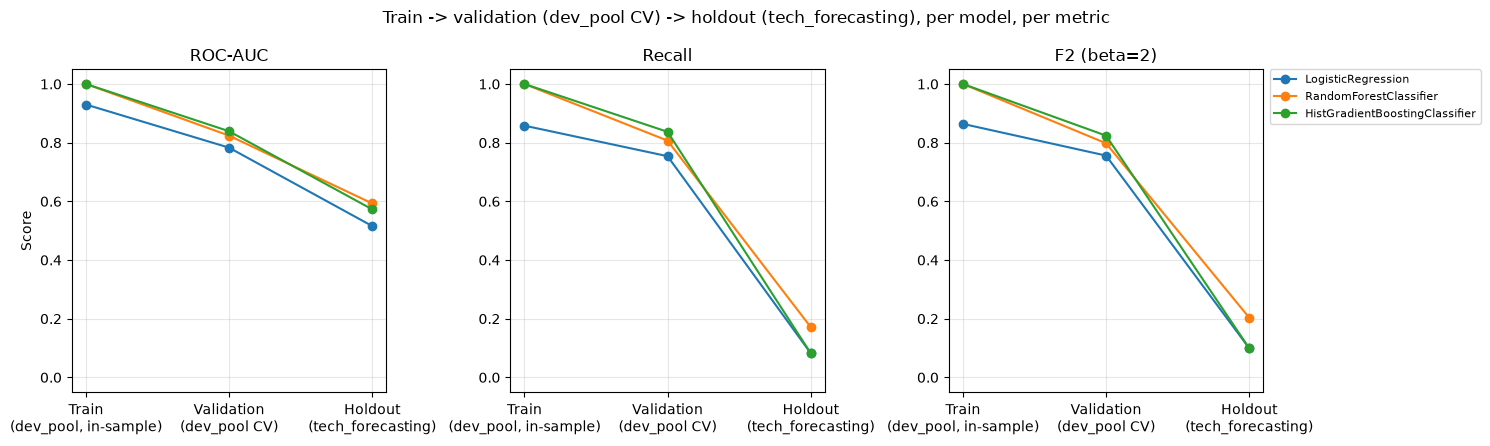

In [39]:
stage_cols = {
    "ROC-AUC": ("train_auc", "validation_auc_devpool", "holdout_auc"),
    "Recall": ("train_recall", "validation_recall_devpool", "holdout_recall"),
    "F2 (beta=2)": ("train_f2", "validation_f2_devpool", "holdout_f2"),
}
stage_labels = ["Train\n(dev_pool, in-sample)", "Validation\n(dev_pool CV)", "Holdout\n(tech_forecasting)"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True)
for ax, (metric_name, (train_col, val_col, hold_col)) in zip(axes, stage_cols.items()):
    for model_name in holdout_df.index:
        row = holdout_df.loc[model_name]
        ax.plot(range(3), [row[train_col], row[val_col], row[hold_col]], marker="o", label=model_name)
    ax.set_xticks(range(3))
    ax.set_xticklabels(stage_labels)
    ax.set_title(metric_name)
    ax.set_ylim(-0.05, 1.05)

axes[0].set_ylabel("Score")
axes[-1].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=8, borderaxespad=0)
fig.suptitle("Train -> validation (dev_pool CV) -> holdout (tech_forecasting), per model, per metric")
plt.tight_layout()
plt.show()

**Hard finding — Recall and F2 collapse far more violently than ROC-AUC, and this is exactly
what ROC-AUC alone was hiding.** `validation_recall_devpool` (73.7–83.7%, close to §13.2's
pooled numbers) drops to `holdout_recall` of **8.3% (`LogisticRegression`), 17.2%
(`RandomForestClassifier`), 8.3% (`HistGradientBoostingClassifier`)** on `tech_forecasting`.
`holdout_auc` (0.516–0.593) already read as "barely better than chance," but ROC-AUC is
threshold-independent and can look almost survivable next to this: at the classifier's actual
default 0.5 cutoff — the threshold a deployed system would use — only **8–17% of the true
positives in this unseen use case get flagged at all**, down from 74–84% in-distribution. F2
tells the same story (0.100–0.204 holdout vs. 0.756–0.824 validation), since F2 weights recall
heavily. This is the sharpest evidence in this notebook that a fixed 0.5 threshold, calibrated
implicitly to the training use cases' own score distribution, is not a decision that survives
contact with a new domain — `reports/wf_ensemble_report.md` §4's calibration-only step for new
use cases (isotonic/Platt scaling, not a full retrain) is directly the fix this points at.

**Hard finding — the train → validation gap (`train_auc` 0.93–1.00 → `validation_auc_devpool`
0.783–0.839) is smaller than the validation → holdout gap (→ 0.516–0.593).** Ordinary
overfitting to the 5 training use cases explains only part of the total collapse; most of it
is the domain-shift problem §14.1's embedding-distance/`citation_velocity` analysis already
pointed at. Regularizing the tree models further would close some of the first gap, not the
second — consistent with `sf_logo_fold_strategy.ipynb` §3.2's same decomposition run across
all 6 use cases (not just this one), which finds the identical pattern with the domain-shift
gap consistently the larger of the two.


## 15. Top 3 baseline classifier candidates — shortlist and merits

**Read the caveats first, not last this time:** every number below is in-distribution,
binary (`positive`-vs-`negative`), on a minimal feature set (embedding + `citation_velocity`
only), and §13.1/§14 both found real limits — the top-2 ranking isn't statistically
distinguishable from fold noise, and all three candidates collapse close to chance on a
genuinely held-out use case. None of these three should be treated as "the" Week-3
baseline without re-running this comparison once term-overlap, cleaned `venue`, and
`author_count` (§11) are actually built, and without a per-use-case
calibration/retraining plan given §14's generalization numbers.

| Rank | Model | In-distribution ROC-AUC (§13) | Held-out (`tech_forecasting`) ROC-AUC (§14) | Key properties | Why it earns a spot |
|---|---|---|---|---|---|
| 1 (tied with #2 — §13.1) | **`HistGradientBoostingClassifier`** (or an equivalent gradient-boosted-trees library, e.g. LightGBM/CatBoost) | 0.821 | 0.573 | Histogram-based gradient boosting; native handling of missing values (no imputation step needed — respects the NULL≠0 convention directly); captures non-linear interactions between metadata and embedding dimensions; no feature scaling required | Highest raw in-distribution AUC, but §13.1's paired test found its lead over `RandomForestClassifier` is **not** statistically significant (p≈0.073) — list this and #2 as a tied pair, not a clean 1st/2nd. |
| 1 (tied with #1 — §13.1) | **`RandomForestClassifier`** | 0.811 | **0.593** (best of the three held-out) | Bagged decision trees; robust to outliers/skew without a log-transform; built-in feature-importance ranking, useful as an ongoing leakage/confound check (watch for `has_abstract`/raw `citation_count` dominating); fewer hyperparameters than boosting | Statistically indistinguishable from #1 in-distribution, and actually generalized *better* to the held-out use case (§14.2) — a genuinely useful data point against automatically picking the in-distribution "winner." A structurally different model (bagging vs. boosting) from #1, valuable as a cross-check on feature-importance rankings. |
| 3 | **`LogisticRegression`** (`class_weight="balanced"`, on standardized embeddings + engineered features) | 0.774 | 0.516 | Linear decision boundary; fast to fit/score at this dataset size; directly interpretable coefficients; well-calibrated probabilities without extra calibration machinery, which matters since the eventual use is a *ranked* probability over the unreviewed pool | Significantly behind both tree-based candidates in-distribution (§13.1: p≈0.011–0.012 vs. each) — no longer a close call, a checked one. Still far above the dummy floor, and the right choice when interpretability or calibration matters more than the last few points of AUC. |

**Not shortlisted, and why (unchanged from v1):** a plain `LinearSVC`/SVM was not tested —
probability calibration for an SVM needs an extra step (Platt scaling) the three
candidates above get for free, for no clear upside on a dataset this size. A neural
network (small MLP) was not tested either — nothing about this problem's size (a few
thousand rows) or feature structure (a single pre-computed sentence embedding, not raw
text needing its own representation learning) suggests it would beat a boosted-tree or
linear model enough to justify the extra tuning/calibration burden as a *baseline*.


## Where to go next

- `sf_eda_firstrun.ipynb` — the v1 pass this notebook supersedes, kept as a historical
  record of what was computed and judged before this critical-thinking review.
- `reports/wf_eda_fe_report.md` — the fuller feature-engineering decision trail §11 draws
  on.
- `notebooks/experiments/wf_fold_pca_test.ipynb` — the fold-design this notebook's §12–§14
  build on and, in §14, directly re-verify for a different feature set/candidate list.
- `notebooks/experiments/run_comparisons.ipynb` §4 — the paired-significance-test method
  reused in §13.1.
- Root `CONTRIBUTING.md` — this project's non-negotiable conventions (NULL ≠ 0, cross-validate
  honestly, label which critic is speaking) — everything above tries to follow them.
